In [1]:
#!pip install datasets
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/nlp_final_project/'

Mounted at /content/drive


In [2]:
from datasets import load_dataset
import pandas as pd

df_sentiment = pd.read_csv(
    path + 'Sentences_AllAgree.txt',
    sep='@',
    names=['sentence', 'label'],
    encoding='latin-1'
)

print(df_sentiment.shape)
print(df_sentiment['label'].value_counts())
df_sentiment.head(10)

(2264, 2)
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,positive
7,Consolidated net sales increased 16 % to reach...,positive
8,Foundries division reports its sales increased...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",positive


In [3]:
df_sentiment['label'].value_counts()

,count
label,
neutral,1391
positive,570
negative,303


In [4]:
label_map = {
    'negative': 0,
    'neutral':  1,
    'positive': 2
}

df_sentiment['labels'] = df_sentiment['label'].map(label_map)
df_sentiment = df_sentiment.rename(columns={'label': 'label_name'})
df_sentiment.head(10)

,sentence,label_name,labels
0,"According to Gran , the company has no plans t...",neutral,1
1,"For the last quarter of 2010 , Componenta 's n...",positive,2
2,"In the third quarter of 2010 , net sales incre...",positive,2
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,2
5,Finnish Talentum reports its operating profit ...,positive,2
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,positive,2
7,Consolidated net sales increased 16 % to reach...,positive,2
8,Foundries division reports its sales increased...,positive,2
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",positive,2


In [5]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df_sentiment,
    test_size=0.15,
    random_state=42,
    stratify=df_sentiment['labels']
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=42,
    stratify=train_val_df['labels']
)

print(f"Train:      {len(train_df)} records")
print(f"Validation: {len(val_df)} records")
print(f"Test:       {len(test_df)} records")

Train:      1635 records
Validation: 289 records
Test:       340 records


In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset, DatasetDict

tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_function(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length = 512)

raw_datasets = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

print(f"Tokenized input shape: {len(tokenized_datasets['train'][0]['input_ids'])} tokens")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1635 [00:00<?, ? examples/s]

Map:   0%|          | 0/289 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Tokenized input shape: 512 tokens


In [7]:
id2label = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

label2id = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f"Model has {model.num_parameters():,} parameters")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model has 124,647,939 parameters


In [8]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted')
    }

In [9]:
training_args = TrainingArguments(
    output_dir=path + 'sentiment_model',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir=path + 'logs',
    logging_steps=10,
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [10]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.133702,0.137019,0.958478,0.946675,0.958812
2,0.015011,0.178262,0.961938,0.943471,0.962702
3,0.079884,0.133028,0.968858,0.952746,0.969233
4,0.061738,0.112633,0.982699,0.973964,0.982705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=412, training_loss=0.16532399383310264, metrics={'train_runtime': 121.6336, 'train_samples_per_second': 53.768, 'train_steps_per_second': 3.387, 'total_flos': 1720761751941120.0, 'train_loss': 0.16532399383310264, 'epoch': 4.0})

In [12]:
test_results = trainer.evaluate(tokenized_datasets['test'])
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")

Test Accuracy: 0.9882


<Figure size 1200x1000 with 0 Axes>

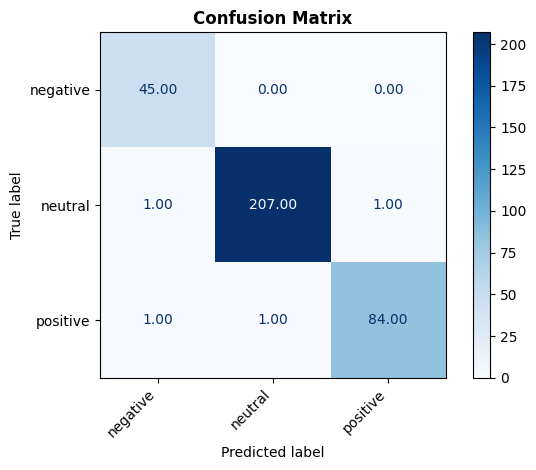

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['negative', 'neutral', 'positive']

predictions_output = trainer.predict(tokenized_datasets['test'])
logits = predictions_output.predictions
labels_true = predictions_output.label_ids
predictions = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels_true, predictions)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='.2f')
plt.title('Confusion Matrix', fontweight ='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    labels_true,
    predictions,
    target_names=class_names
))

              precision    recall  f1-score   support

    negative       0.96      1.00      0.98        45
     neutral       1.00      0.99      0.99       209
    positive       0.99      0.98      0.98        86

    accuracy                           0.99       340
   macro avg       0.98      0.99      0.98       340
weighted avg       0.99      0.99      0.99       340



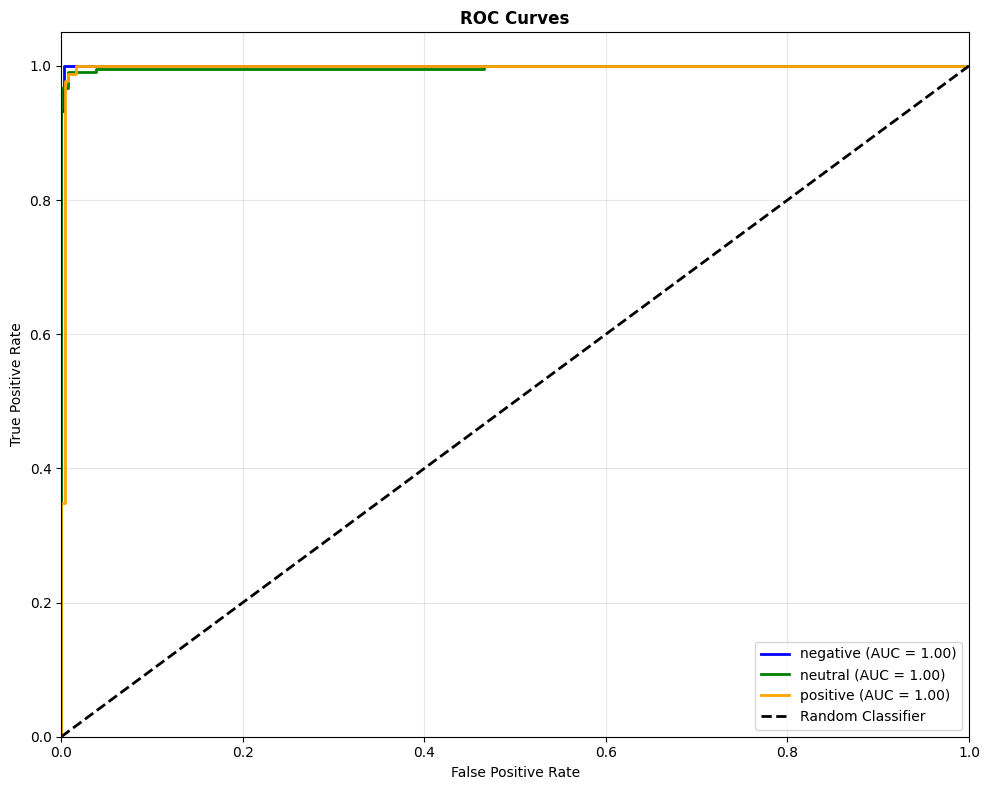

In [31]:
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from scipy.special import softmax

probabilities = softmax(logits, axis=-1)
labels_binarized = label_binarize(labels_true, classes=range(len(class_names)))

fpr = dict()
tpr = dict()
roc_auc = dict()
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'green', 'orange'])
for i, color in zip(range(len(class_names)), colors):
    fpr[i], tpr[i], _ = roc_curve(labels_binarized[:, i], probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontweight = 'bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Training Labeled Dataset Citation**

@article{Malo2014GoodDO,
  title={Good debt or bad debt: Detecting semantic orientations in economic texts},
  author={P. Malo and A. Sinha and P. Korhonen and J. Wallenius and P. Takala},
  journal={Journal of the Association for Information Science and Technology},
  year={2014},
  volume={65}
}